# CA interaction results

This notebook only reads results saved by `cf_ca_interaction_compute.ipynb`. Adjacent salt transitions are shown first, followed by their cumulative interaction change relative to the selected reference. The optional direct lowest-to-highest result is used only as a closure check. Figures use at most two columns and contain no titles or explanatory annotations beyond axes, ticks, and legends.

In [1]:
from __future__ import annotations

import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import cf_ca_interaction as interaction

HERE = Path.cwd().resolve()
if not (HERE / "cf_ca_interaction.py").exists():
    raise RuntimeError("Run this notebook from smpl/curvefit")

# 1. SETTINGS THAT MUST MATCH BETWEEN COMPUTE AND RESULTS.
# Copy this whole block into the results notebook before loading saved results.
# Relative-report default: zero-salt comparison; geometry and pair mode remain explicit choices.
FIT_SOURCE = "aniso"  # "iso" or "aniso"
COMPARISON_MODE = "adjacent"  # "adjacent" or "single_reference"
REFERENCE_CONDITION = "zero"  # "zero" or "highest"
ANISOTROPIC_GEOMETRY = True  # True for anisotropic geometry; False for isotropic geometry.
LOCAL_EXPANSION_RANGE_MULTIPLIER = 1.0  # ell = this value / k_eff; the note uses 1.0.
INFER_ABSOLUTE_COEFFICIENTS = False  # Also fit c2,c4 independently for every salt condition.
NONLOCAL_METHOD = "model_free"  # "yukawa" (legacy default in the tool) or interaction-form-independent "model_free".
# END MATCHED SETTINGS

if COMPARISON_MODE not in {"adjacent", "single_reference"}:
    raise ValueError("COMPARISON_MODE must be 'adjacent' or 'single_reference'")
if REFERENCE_CONDITION not in {"zero", "highest"}:
    raise ValueError("REFERENCE_CONDITION must be 'zero' or 'highest'")
if NONLOCAL_METHOD not in {"yukawa", "model_free"}:
    raise ValueError("NONLOCAL_METHOD must be 'yukawa' or 'model_free'")
REFERENCE_TAG = "0mM" if REFERENCE_CONDITION == "zero" else "highest_salt"
COMPARISON_TAG = "_adjacent" if COMPARISON_MODE == "adjacent" else ""  # Keep the former single-reference path compatible.
OUTPUT_SUFFIX = "_geometry_aniso" if ANISOTROPIC_GEOMETRY else ""
NONLOCAL_TAG = "" if NONLOCAL_METHOD == "yukawa" else "_nonlocal_model_free"
OUTPUT_DIR = HERE / "output" / f"ca_interaction_refactored_{REFERENCE_TAG}_{FIT_SOURCE}{COMPARISON_TAG}{OUTPUT_SUFFIX}{NONLOCAL_TAG}"
COEFFICIENT_TABLE = OUTPUT_DIR / "effective_local_cell_coefficients.csv"
FIT_INPUT_TABLE = OUTPUT_DIR / "radial_fit_inputs.csv"
INVARIANT_MOMENT_TABLE = OUTPUT_DIR / "local_invariant_moments.csv"
STRUCTURE_HISTOGRAM_TABLE = OUTPUT_DIR / "local_structure_histograms.csv"
STRUCTURE_JOINT_HISTOGRAM_TABLE = OUTPUT_DIR / "local_structure_joint_histograms.npz"
RECONSTRUCTION_HISTOGRAM_TABLE = OUTPUT_DIR / "local_reconstruction_histograms.csv"
LOCAL_INVARIANT_HISTOGRAM_TABLE = OUTPUT_DIR / "local_invariant_histograms.csv"
STRUCTURE_CORRELATION_TABLE = OUTPUT_DIR / "local_structure_correlations.csv"
INDEPENDENT_COEFFICIENT_TABLE = OUTPUT_DIR / "independent_fourth_order_coefficients.csv"
CUMULATIVE_COEFFICIENT_TABLE = OUTPUT_DIR / "cumulative_local_coefficients.csv"

# 2. RESULTS ALWAYS RELOAD SAVED TABLES; NO RECOMPUTE SWITCH IS NEEDED HERE.
# After loading new data, rerun this notebook from the first cell.

# 3. RESULT-ONLY INTERPRETATION AND ADVANCED-RESULT DISPLAY OPTIONS.
CONDITIONAL_G0_OVER_KREF_BOUNDS = (100.0, 2000.0)
CONDITIONAL_D0_KREF_BOUNDS = (0.1, 1.0)
CONDITIONAL_REFERENCE_GRID_SIZE = 17
CONDITIONAL_ENVELOPE_STANDARD_DEVIATIONS = 1.0
CONDITIONAL_REFERENCE_MODE = "fixed"  # Default avoids selecting one unjustified absolute g0,D0.
CONDITIONAL_CUTOFF_MODE = "finite_cutoff"  # "short_range" sets f2=f4=1; "finite_cutoff" retains f2,f4.
if CONDITIONAL_REFERENCE_MODE not in {"fixed", "family"}:
    raise ValueError("CONDITIONAL_REFERENCE_MODE must be 'fixed' or 'family'")
if CONDITIONAL_CUTOFF_MODE not in {"short_range", "finite_cutoff"}:
    raise ValueError("CONDITIONAL_CUTOFF_MODE must be 'short_range' or 'finite_cutoff'")
SHOW_DISTANT_CORRECTION_IN_FIT = True  # Show only corrections that passed dependence, convergence, and overlap checks.
USE_NONLOCAL_CORRECTED_COEFFICIENTS = True  # All selected pairs must pass; otherwise retain the local-only cumulative coefficients.
FIXED_REFERENCE_G0_OVER_KREF = 5.0
FIXED_REFERENCE_D0_KREF = 1.0
RECONSTRUCTION_KS_WARNING = 0.08
PROJECTION_UNEXPLAINED_WARNING = 0.20
LOCAL_K2_HISTOGRAM_RANGE = (0.0, 1.5)
LOCAL_K4_HISTOGRAM_RANGE = (-0.06, 0.06)
LOCAL_STRUCTURE_HISTOGRAM_RANGES = {"kappa": (0.0, 5.0), "kappa_tau": (-5.0, 5.0), "kappa_prime": (-5.0, 5.0)}
K2_DISTRIBUTION_RANGE = (0.0, 1.25)
K4_DISTRIBUTION_RANGE = (-0.05, 0.05)
plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 190, "axes.grid": True, "grid.alpha": 0.22})

## Load the calculated results

Run `cf_ca_interaction_compute.ipynb` first whenever the input fit or analysis settings change.

In [2]:
if not COEFFICIENT_TABLE.exists() or not FIT_INPUT_TABLE.exists():
    raise FileNotFoundError("Run cf_ca_interaction_compute.ipynb first")
with COEFFICIENT_TABLE.open(newline="", encoding="utf-8") as handle:
    coefficient_rows = list(csv.DictReader(handle))
with FIT_INPUT_TABLE.open(newline="", encoding="utf-8") as handle:
    fit_input_rows = list(csv.DictReader(handle))
if not INVARIANT_MOMENT_TABLE.exists() or not INDEPENDENT_COEFFICIENT_TABLE.exists():
    raise FileNotFoundError("Run the direct local inference cell in cf_ca_interaction_compute.ipynb")
with INVARIANT_MOMENT_TABLE.open(newline="", encoding="utf-8") as handle:
    invariant_moment_rows = list(csv.DictReader(handle))
with INDEPENDENT_COEFFICIENT_TABLE.open(newline="", encoding="utf-8") as handle:
    independent_coefficient_rows = list(csv.DictReader(handle))
structure_histogram_rows = []
structure_correlation_rows = []
if STRUCTURE_HISTOGRAM_TABLE.exists() and STRUCTURE_CORRELATION_TABLE.exists():
    with STRUCTURE_HISTOGRAM_TABLE.open(newline="", encoding="utf-8") as handle:
        structure_histogram_rows = list(csv.DictReader(handle))
    with STRUCTURE_CORRELATION_TABLE.open(newline="", encoding="utf-8") as handle:
        structure_correlation_rows = list(csv.DictReader(handle))
else:
    print("Measured structure tables are absent; rerun the local inference cell in the compute notebook.")
joint_structure_data = None
if STRUCTURE_JOINT_HISTOGRAM_TABLE.exists():
    with np.load(STRUCTURE_JOINT_HISTOGRAM_TABLE, allow_pickle=False) as payload:
        joint_structure_data = {name: payload[name].copy() for name in payload.files}
else:
    print("Joint structure histograms are absent; rerun random-wave sampling in the compute notebook.")
reconstruction_histogram_rows = []
if RECONSTRUCTION_HISTOGRAM_TABLE.exists():
    with RECONSTRUCTION_HISTOGRAM_TABLE.open(newline="", encoding="utf-8") as handle:
        reconstruction_histogram_rows = list(csv.DictReader(handle))
else:
    print("Fitted structure histograms are absent; rerun the local inference cell in the compute notebook.")
local_invariant_histogram_rows = []
if LOCAL_INVARIANT_HISTOGRAM_TABLE.exists():
    with LOCAL_INVARIANT_HISTOGRAM_TABLE.open(newline="", encoding="utf-8") as handle:
        local_invariant_histogram_rows = list(csv.DictReader(handle))
else:
    print("K2,K4 histograms are absent; rerun random-wave sampling with invariant histograms enabled.")
fit_by_salt = {float(row["concentration_mM"]): row for row in fit_input_rows}
salt = np.array([float(row["concentration_mM"]) for row in coefficient_rows])
if any(float(value) not in fit_by_salt for value in salt):
    raise RuntimeError("coefficient and fitted-spectrum tables contain different conditions")
k_eff = np.array([float(fit_by_salt[float(value)]["k_eff"]) for value in salt])
r_sigma_k = np.array([float(fit_by_salt[float(value)]["r_sigma_k"]) for value in salt])
reference_index = int(np.argmin(salt) if REFERENCE_CONDITION == "zero" else np.argmax(salt))
reference_salt = salt[reference_index]
saved_reference = {float(row["reference_concentration_mM"]) for row in fit_input_rows if row.get("reference_concentration_mM") not in (None, "")}
if saved_reference and (len(saved_reference) != 1 or not np.isclose(next(iter(saved_reference)), reference_salt)):
    raise RuntimeError("The result files were calculated with a different reference condition")
saved_modes = {row.get("comparison_mode") for row in fit_input_rows if row.get("comparison_mode")}
if saved_modes and saved_modes != {COMPARISON_MODE}:
    raise RuntimeError("The result files were calculated with a different comparison mode")
saved_expansion_ranges = {float(row.get("local_expansion_range_times_kref", row.get("local_cell_length_times_kref"))) for row in coefficient_rows if row.get("local_expansion_range_times_kref", row.get("local_cell_length_times_kref")) not in (None, "")}
if saved_expansion_ranges and (len(saved_expansion_ranges) != 1 or not np.isclose(next(iter(saved_expansion_ranges)), LOCAL_EXPANSION_RANGE_MULTIPLIER)):
    raise RuntimeError("The result files were calculated with a different LOCAL_EXPANSION_RANGE_MULTIPLIER")
if COMPARISON_MODE == "single_reference" and not np.allclose([float(coefficient_rows[reference_index]["delta_c2_kref"]), float(coefficient_rows[reference_index]["delta_c4_kref3"])], 0.0, atol=1e-12):
    raise RuntimeError("The selected reference row does not have zero coefficient change")
k_ref = k_eff[reference_index]
delta_c2 = np.array([float(row["delta_c2_kref"]) for row in coefficient_rows])
delta_c4 = np.array([float(row["delta_c4_kref3"]) for row in coefficient_rows])
source_salt_by_target = {float(row["concentration_mM"]): float(row.get("source_concentration_mM", reference_salt)) for row in coefficient_rows}
coefficient_covariances = np.array([[[float(row["cov_c2_c2"]), float(row["cov_c2_c4"])], [float(row["cov_c2_c4"]), float(row["cov_c4_c4"])]] for row in coefficient_rows])
if CUMULATIVE_COEFFICIENT_TABLE.exists():
    with CUMULATIVE_COEFFICIENT_TABLE.open(newline="", encoding="utf-8") as handle:
        cumulative_by_salt = {float(row["concentration_mM"]): row for row in csv.DictReader(handle)}
    cumulative_delta_c2 = np.array([float(cumulative_by_salt[float(value)]["delta_c2_kref"]) for value in salt])
    cumulative_delta_c4 = np.array([float(cumulative_by_salt[float(value)]["delta_c4_kref3"]) for value in salt])
    cumulative_coefficient_covariances = np.array([[[float(cumulative_by_salt[float(value)]["cov_c2_c2"]), float(cumulative_by_salt[float(value)]["cov_c2_c4"])], [float(cumulative_by_salt[float(value)]["cov_c2_c4"]), float(cumulative_by_salt[float(value)]["cov_c4_c4"])]] for value in salt])
else:
    cumulative_delta_c2, cumulative_delta_c4 = delta_c2.copy(), delta_c4.copy()
    cumulative_coefficient_covariances = coefficient_covariances.copy()
corrected_coefficient_path = OUTPUT_DIR / "nonlocal_corrected_coefficients.csv"
if USE_NONLOCAL_CORRECTED_COEFFICIENTS and corrected_coefficient_path.exists():
    with corrected_coefficient_path.open(newline="", encoding="utf-8") as handle:
        corrected_rows = list(csv.DictReader(handle))
    use_corrected = bool(corrected_rows) and all(row.get("correction_applied", "False").lower() == "true" for row in corrected_rows)
    required_covariance = {"cov_c2_c2_corrected", "cov_c2_c4_corrected", "cov_c4_c4_corrected"}
    use_corrected = use_corrected and required_covariance.issubset(corrected_rows[0])
    if use_corrected:
        cumulative_values = {float(reference_salt): np.zeros(2)}
        cumulative_covariances = {float(reference_salt): np.zeros((2,2))}
        pending = corrected_rows.copy()
        while pending:
            progress = False
            for row in pending.copy():
                source = float(row["source_concentration_mM"]); target = float(row["target_concentration_mM"])
                step = np.array([float(row["delta_c2_kref_corrected"]), float(row["delta_c4_kref3_corrected"])])
                covariance = np.array([[float(row["cov_c2_c2_corrected"]), float(row["cov_c2_c4_corrected"])], [float(row["cov_c2_c4_corrected"]), float(row["cov_c4_c4_corrected"])]])
                if source in cumulative_values:
                    cumulative_values[target] = cumulative_values[source] + step
                    cumulative_covariances[target] = cumulative_covariances[source] + covariance
                elif target in cumulative_values:
                    cumulative_values[source] = cumulative_values[target] - step
                    cumulative_covariances[source] = cumulative_covariances[target] + covariance
                else:
                    continue
                pending.remove(row); progress = True
            if not progress:
                raise RuntimeError("Corrected comparison pairs do not form a connected chain to the selected reference")
        if set(map(float, salt)) != set(cumulative_values):
            raise RuntimeError("Corrected comparison pairs do not cover the loaded salt series")
        cumulative_delta_c2 = np.array([cumulative_values[float(value)][0] for value in salt])
        cumulative_delta_c4 = np.array([cumulative_values[float(value)][1] for value in salt])
        cumulative_coefficient_covariances = np.array([cumulative_covariances[float(value)] for value in salt])
        print(f"using cumulative {NONLOCAL_METHOD} corrected coefficients")
    else:
        print("At least one distant-correction pair failed validation; all coefficient plots retain the local-only cumulative values.")
projection_unexplained = np.array([float(row.get("projection_unexplained_fraction", np.nan)) for row in coefficient_rows])
if any(row.get("inference_method") != "linked_maximum_entropy" for row in coefficient_rows):
    raise RuntimeError("The saved coefficients predate direct linked inference; rerun the compute notebook")
DISCRETE_SALT_COLORS = ("#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#17becf")
DISCRETE_SALT_MARKERS = ("o", "s", "^", "v", "D", "P", "X", "*")
if len(salt) > len(DISCRETE_SALT_COLORS):
    raise ValueError("Add more salt colors and markers for the loaded series")
colors = DISCRETE_SALT_COLORS[:len(salt)]
markers = DISCRETE_SALT_MARKERS[:len(salt)]
print(f"loaded {len(salt)} conditions; reference={reference_salt:g} mM; k_ref={k_ref:.8g}")

using cumulative model_free corrected coefficients
loaded 8 conditions; reference=0 mM; k_ref=0.052411293


## Anisotropy input

When anisotropic geometry is enabled, these are the fixed principal stretches and Hencky strains supplied by the scattering fit. They are inputs to the geometric calculation, not interaction-fit parameters.

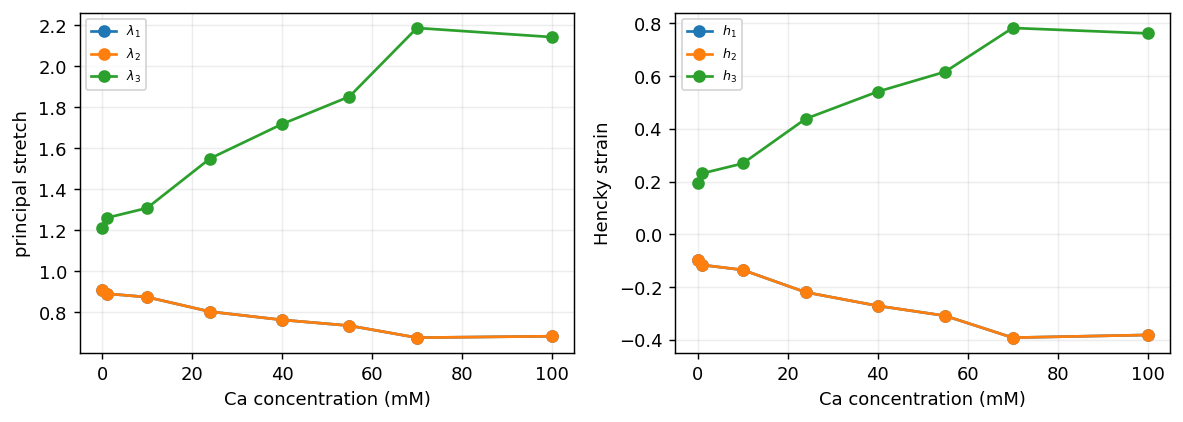

In [3]:
anisotropy_path = OUTPUT_DIR / "anisotropy_inputs.csv"
if ANISOTROPIC_GEOMETRY:
    if not anisotropy_path.exists():
        raise FileNotFoundError("Run the compute notebook with ANISOTROPIC_GEOMETRY=True")
    with anisotropy_path.open(newline="", encoding="utf-8") as handle:
        anisotropy_rows = list(csv.DictReader(handle))
    anisotropy_salt = np.array([float(row["concentration_mM"]) for row in anisotropy_rows])
    principal_stretch = np.array([[float(row[f"lambda{index}"]) for index in (1,2,3)] for row in anisotropy_rows])
    principal_strain = np.array([[float(row[f"h{index}"]) for index in (1,2,3)] for row in anisotropy_rows])
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.35))
    for index in range(3):
        axes[0].plot(anisotropy_salt, principal_stretch[:,index], marker="o", label=rf"$\lambda_{index+1}$")
        axes[1].plot(anisotropy_salt, principal_strain[:,index], marker="o", label=rf"$h_{index+1}$")
    for axis, ylabel in zip(axes, (r"principal stretch", r"Hencky strain")):
        axis.set(xlabel="Ca concentration (mM)", ylabel=ylabel); axis.legend(fontsize=7)
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "anisotropy_inputs.png"); plt.show()
else:
    print("anisotropic geometry disabled")

## 1. Measured local structure

The distributions of $\kappa$, $\kappa'$, and $\kappa\tau$ are the primary observations. Correlations are calculated from their magnitudes because the signs of $\kappa'$ and $\kappa\tau$ cancel under the symmetries of the random-wave ensemble. The coefficient plots that follow summarize only the part represented by the local expression in the note.

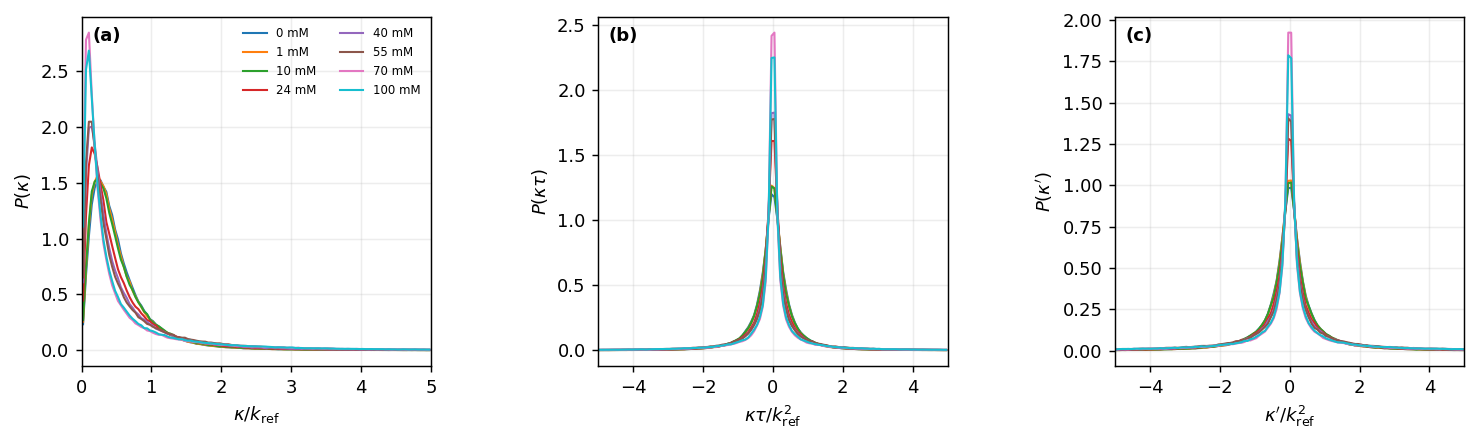

In [4]:
if structure_histogram_rows:
    fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.5))
    structure_specs = (("kappa", r"$\kappa/k_{\rm ref}$", r"$P(\kappa)$"), ("kappa_tau", r"$\kappa\tau/k_{\rm ref}^2$", r"$P(\kappa\tau)$"), ("kappa_prime", r"$\kappa'/k_{\rm ref}^2$", r"$P(\kappa')$"))
    for axis, (variable, xlabel, ylabel) in zip(axes, structure_specs):
        for color, concentration in zip(colors, salt):
            measured_rows = [row for row in structure_histogram_rows if float(row["concentration_mM"]) == concentration and row["variable"] == variable]
            measured_coordinate = np.asarray([float(row["coordinate"]) for row in measured_rows])
            measured_density = np.asarray([float(row["density"]) for row in measured_rows])
            axis.plot(measured_coordinate, measured_density, color=color, lw=1.15, label=f"{concentration:g} mM")
        axis.set(xlabel=xlabel, ylabel=ylabel, xlim=LOCAL_STRUCTURE_HISTOGRAM_RANGES[variable])
    for axis, panel_label in zip(axes, ("(a)", "(b)", "(c)")):
        axis.set_box_aspect(1)
        axis.text(0.03, 0.97, panel_label, transform=axis.transAxes, ha="left", va="top", fontweight="bold")
    axes[0].legend(loc="upper right", ncol=2, fontsize=6.5, frameon=False)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fundamental_kappa_kappatau_kappaprime_distributions.png", bbox_inches="tight")
    plt.show()


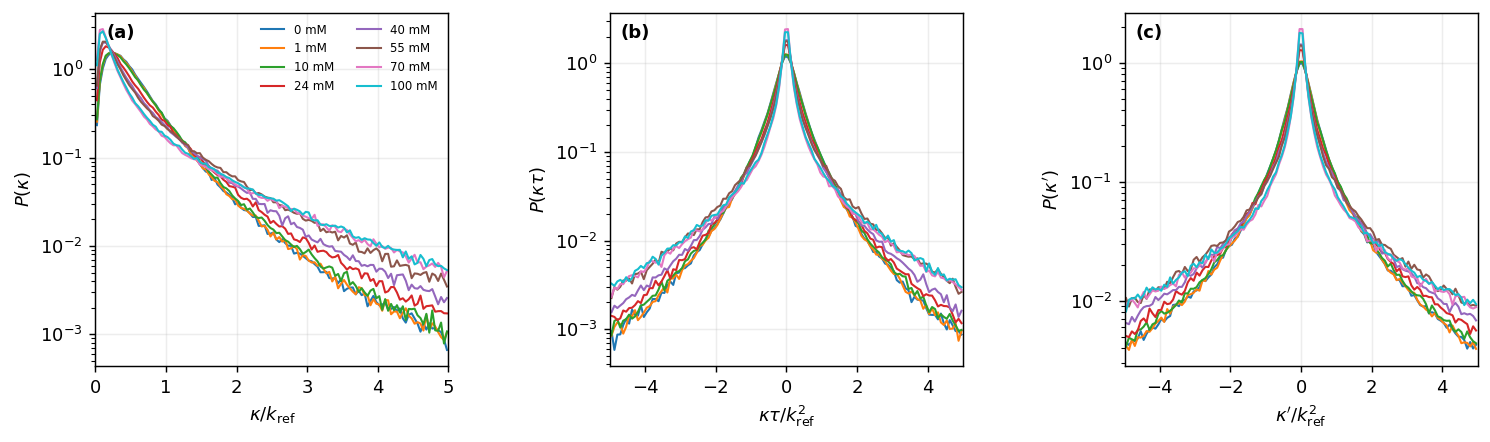

In [5]:
if structure_histogram_rows:
    fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.5))

    structure_specs = (
        ("kappa", r"$\kappa/k_{\rm ref}$", r"$P(\kappa)$"),
        ("kappa_tau", r"$\kappa\tau/k_{\rm ref}^2$", r"$P(\kappa\tau)$"),
        ("kappa_prime", r"$\kappa'/k_{\rm ref}^2$", r"$P(\kappa')$"),
    )

    for axis, (variable, xlabel, ylabel) in zip(axes, structure_specs):
        for color, concentration in zip(colors, salt):
            measured_rows = [
                row for row in structure_histogram_rows
                if float(row["concentration_mM"]) == concentration
                and row["variable"] == variable
            ]

            coordinate = np.asarray(
                [float(row["coordinate"]) for row in measured_rows]
            )
            density = np.asarray(
                [float(row["density"]) for row in measured_rows]
            )

            # Logarithmic axes cannot display empty histogram bins.
            resolved = np.isfinite(density) & (density > 0.0)

            axis.semilogy(
                coordinate[resolved],
                density[resolved],
                color=color,
                lw=1.15,
                label=f"{concentration:g} mM",
            )

        axis.set(
            xlabel=xlabel,
            ylabel=ylabel,
            xlim=LOCAL_STRUCTURE_HISTOGRAM_RANGES[variable],
        )

    for axis, panel_label in zip(axes, ("(a)", "(b)", "(c)")):
        axis.set_box_aspect(1)
        axis.text(
            0.03,
            0.97,
            panel_label,
            transform=axis.transAxes,
            ha="left",
            va="top",
            fontweight="bold",
        )

    axes[0].legend(
        loc="upper right",
        ncol=2,
        fontsize=6.5,
        frameon=False,
    )

    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR
        / "fundamental_kappa_kappatau_kappaprime_tail_distributions.png",
        bbox_inches="tight",
    )
    plt.show()

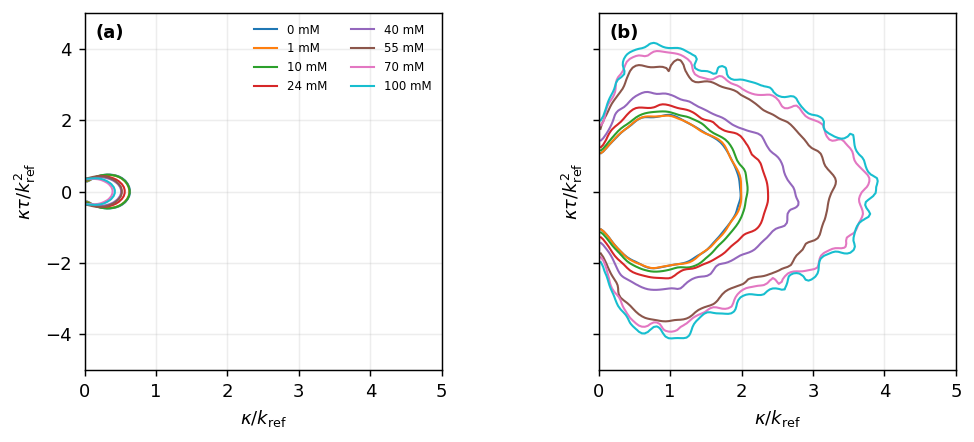

In [6]:
from scipy.ndimage import gaussian_filter

JOINT_CONTOUR_SMOOTHING = 2  # Width in histogram bins

if joint_structure_data is not None:
    saved_salt = np.asarray(
        joint_structure_data["concentrations"],
        dtype=float,
    )
    if set(saved_salt) != set(map(float, salt)):
        raise RuntimeError(
            "The saved joint distributions do not match the loaded salt series"
        )

    saved_k_ref = float(
        np.asarray(joint_structure_data["normalization_k_ref"])
    )
    if not np.isclose(saved_k_ref, k_ref):
        raise RuntimeError(
            "The saved joint distributions use a different k_ref"
        )

    x_variables = [
        str(value)
        for value in joint_structure_data["x_variables"]
    ]
    y_variables = [
        str(value)
        for value in joint_structure_data["y_variables"]
    ]

    pair_index = next(
        index
        for index, pair in enumerate(zip(x_variables, y_variables))
        if pair == ("kappa", "kappa_tau")
    )

    x_edges = joint_structure_data["x_edges"][pair_index]
    y_edges = joint_structure_data["y_edges"][pair_index]

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

    bin_area = (
        np.diff(x_edges)[:, None]
        * np.diff(y_edges)[None, :]
    )

    contour_probabilities = (0.5, 0.95)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(8.4, 3.5),
        sharex=True,
        sharey=True,
    )

    for axis, contour_probability in zip(
        axes,
        contour_probabilities,
    ):
        for color, concentration in zip(colors, salt):
            concentration_index = int(
                np.flatnonzero(
                    np.isclose(saved_salt, concentration)
                )[0]
            )

            raw_probability_mass = joint_structure_data[
                "probability_mass"
            ][
                concentration_index,
                pair_index,
            ]

            retained_probability = float(
                joint_structure_data["retained_probability"][
                    concentration_index,
                    pair_index,
                ]
            )

            if retained_probability < contour_probability:
                raise RuntimeError(
                    f"{concentration:g} mM retains only "
                    f"{retained_probability:.3f} probability"
                )

            # Smooth the two-dimensional probability mass.
            smoothed_probability_mass = gaussian_filter(
                raw_probability_mass,
                sigma=JOINT_CONTOUR_SMOOTHING,
                mode="reflect",
            )

            # Preserve the probability contained in the saved range.
            smoothed_probability_mass *= (
                retained_probability
                / smoothed_probability_mass.sum()
            )

            smoothed_density = (
                smoothed_probability_mass / bin_area
            )

            # Highest-density threshold enclosing the requested mass.
            descending = np.argsort(
                smoothed_density.ravel()
            )[::-1]

            cumulative_mass = np.cumsum(
                smoothed_probability_mass.ravel()[descending]
            )

            threshold_index = min(
                int(
                    np.searchsorted(
                        cumulative_mass,
                        contour_probability,
                        side="left",
                    )
                ),
                len(descending) - 1,
            )

            density_threshold = smoothed_density.ravel()[
                descending[threshold_index]
            ]

            axis.contour(
                x_centers,
                y_centers,
                smoothed_density.T,
                levels=[density_threshold],
                colors=[color],
                linewidths=1.15,
            )

            if contour_probability == contour_probabilities[0]:
                axis.plot(
                    [],
                    [],
                    color=color,
                    lw=1.15,
                    label=f"{concentration:g} mM",
                )

        axis.set(
            xlabel=r"$\kappa/k_{\rm ref}$",
            ylabel=r"$\kappa\tau/k_{\rm ref}^2$",
            xlim=(x_edges[0], x_edges[-1]),
            ylim=(y_edges[0], y_edges[-1]),
        )
        axis.set_box_aspect(1)

    for axis, panel_label in zip(axes, ("(a)", "(b)")):
        axis.text(
            0.03,
            0.97,
            panel_label,
            transform=axis.transAxes,
            ha="left",
            va="top",
            fontweight="bold",
        )

    axes[0].legend(
        loc="upper right",
        ncol=2,
        fontsize=6.5,
        frameon=False,
    )

    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR
        / "fundamental_kappa_kappatau_5pct_95pct_contours.png",
        bbox_inches="tight",
    )
    plt.show()

## 2. $K_2$, $K_4$, $\Delta c_2$, and $\Delta c_4$

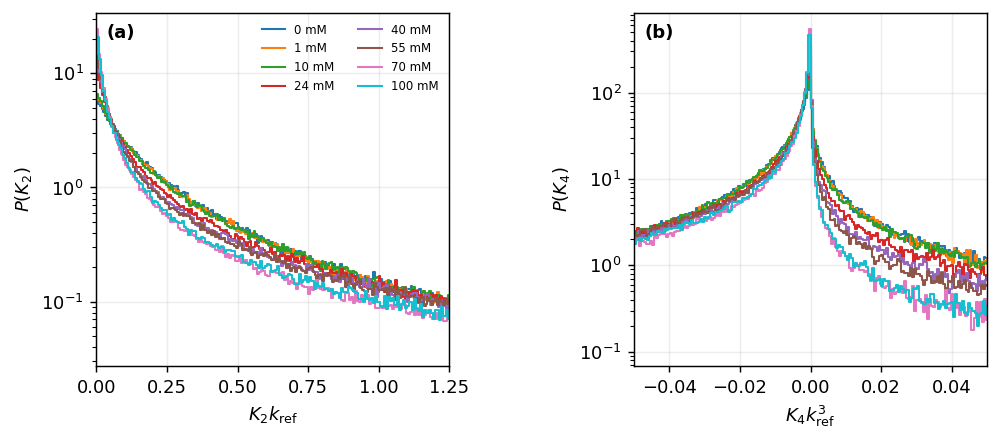

In [14]:
if local_invariant_histogram_rows:
    histogram_salt = {
        float(row["concentration_mM"])
        for row in local_invariant_histogram_rows
    }
    if histogram_salt != set(map(float, salt)):
        raise RuntimeError(
            "The saved K2,K4 histograms do not match the loaded salt series"
        )

    fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.5))

    invariant_specs = (
        ("k2", r"$K_2 k_{\rm ref}$", r"$P(K_2)$"),
        ("k4", r"$K_4 k_{\rm ref}^3$", r"$P(K_4)$"),
    )

    for axis, (variable, xlabel, ylabel) in zip(
        axes,
        invariant_specs,
    ):
        display_range = (
            K2_DISTRIBUTION_RANGE
            if variable == "k2"
            else K4_DISTRIBUTION_RANGE
        )

        for color, concentration, condition_k_eff in zip(
            colors,
            salt,
            k_eff,
        ):
            rows = [
                row
                for row in local_invariant_histogram_rows
                if np.isclose(
                    float(row["concentration_mM"]),
                    concentration,
                )
                and row["variable"] == variable
            ]

            if not rows:
                continue

            expansion_range_kref = (
                LOCAL_EXPANSION_RANGE_MULTIPLIER
                * k_ref
                / condition_k_eff
            )

            coordinate = np.asarray(
                [float(row["coordinate"]) for row in rows]
            ) * expansion_range_kref

            density = np.asarray(
                [float(row["density"]) for row in rows]
            ) / expansion_range_kref

            # Keep only finite positive bins on the logarithmic axis.
            resolved = (
                np.isfinite(coordinate)
                & np.isfinite(density)
                & (density > 0.0)
            )

            axis.step(
                coordinate[resolved],
                density[resolved],
                where="mid",
                color=color,
                lw=1.15,
                label=f"{concentration:g} mM",
            )

        axis.set(
            xlabel=xlabel,
            ylabel=ylabel,
            xlim=display_range,
            yscale="log",
        )
        axis.set_box_aspect(1)

    for axis, panel_label in zip(axes, ("(a)", "(b)")):
        axis.text(
            0.03,
            0.97,
            panel_label,
            transform=axis.transAxes,
            ha="left",
            va="top",
            fontweight="bold",
        )

    axes[0].legend(
        loc="upper right",
        ncol=2,
        fontsize=6.5,
        frameon=False,
    )

    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / "fundamental_K2_K4_distributions.png",
        bbox_inches="tight",
    )
    plt.show()

A2    = 13.1373
A4    = 41.7158
I_bg  = 101.678 mM
chi^2 = 5.365
dof   = 11
chi^2/dof = 0.4877


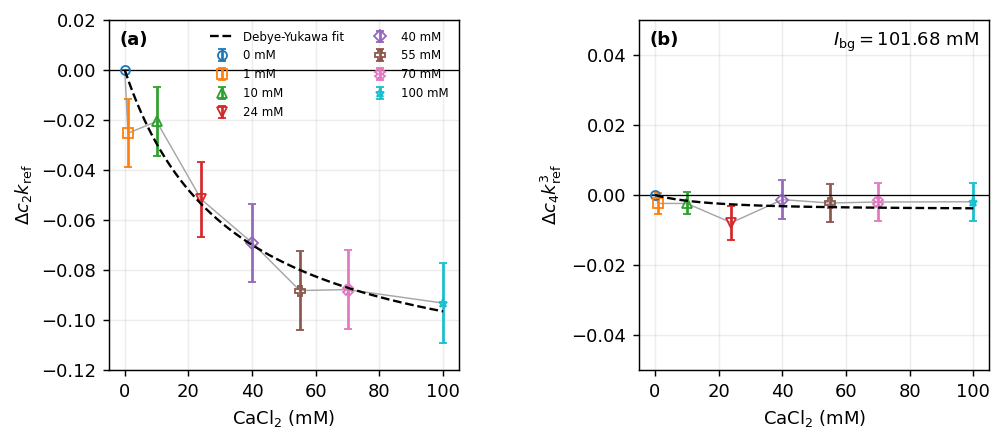

In [16]:
from scipy.optimize import least_squares

coefficient_errors = np.sqrt(
    np.maximum(
        np.diagonal(
            cumulative_coefficient_covariances,
            axis1=1,
            axis2=2
        ),
        0.0
    )
)

# ------------------------------------------------------------
# Debye-Yukawa salt-dependence models
# C and I_bg are both in mM.
# For ideal CaCl2, the added ionic strength is 3 C.
# ------------------------------------------------------------

def delta_c2_model(C, A2, I_bg):
    I = I_bg + 3.0 * C
    return A2 * (1.0 / I - 1.0 / I_bg)


def delta_c4_model(C, A4, I_bg):
    I = I_bg + 3.0 * C
    return A4 * (1.0 / I**2 - 1.0 / I_bg**2)


y2 = np.asarray(cumulative_delta_c2)
y4 = np.asarray(cumulative_delta_c4)

s2 = np.asarray(coefficient_errors[:, 0])
s4 = np.asarray(coefficient_errors[:, 1])
C = np.asarray(salt, dtype=float)

# Exclude points with zero/invalid uncertainty.
# The C=0 reference is automatically reproduced by both models.
mask2 = np.isfinite(y2) & np.isfinite(s2) & (s2 > 0)
mask4 = np.isfinite(y4) & np.isfinite(s4) & (s4 > 0)

# Initial guess for background ionic strength
I_bg_guess = 10.0  # mM

# Obtain reasonable amplitude guesses from the largest-C point
basis2 = 1.0 / (I_bg_guess + 3.0 * C) - 1.0 / I_bg_guess
basis4 = 1.0 / (I_bg_guess + 3.0 * C)**2 - 1.0 / I_bg_guess**2

valid2 = mask2 & (np.abs(basis2) > 0)
valid4 = mask4 & (np.abs(basis4) > 0)

A2_guess = (
    np.sum(y2[valid2] * basis2[valid2] / s2[valid2]**2)
    / np.sum(basis2[valid2]**2 / s2[valid2]**2)
)

A4_guess = (
    np.sum(y4[valid4] * basis4[valid4] / s4[valid4]**2)
    / np.sum(basis4[valid4]**2 / s4[valid4]**2)
)


def residuals(params):
    A2, A4, I_bg = params

    r2 = (
        y2[mask2]
        - delta_c2_model(C[mask2], A2, I_bg)
    ) / s2[mask2]

    r4 = (
        y4[mask4]
        - delta_c4_model(C[mask4], A4, I_bg)
    ) / s4[mask4]

    return np.concatenate((r2, r4))


fit = least_squares(
    residuals,
    x0=[A2_guess, A4_guess, I_bg_guess],
    bounds=([-np.inf, -np.inf, 1e-6],
            [ np.inf,  np.inf, np.inf]),
    x_scale="jac"
)

A2_fit, A4_fit, I_bg_fit = fit.x

print(f"A2    = {A2_fit:.6g}")
print(f"A4    = {A4_fit:.6g}")
print(f"I_bg  = {I_bg_fit:.6g} mM")
print(f"chi^2 = {np.sum(fit.fun**2):.4g}")
print(f"dof   = {fit.fun.size - fit.x.size}")
print(
    f"chi^2/dof = "
    f"{np.sum(fit.fun**2) / (fit.fun.size - fit.x.size):.4g}"
)

# Dense concentration grid for plotting fitted curves
salt_fit = np.linspace(0.0, np.max(C), 400)

c2_fit = delta_c2_model(
    salt_fit,
    A2_fit,
    I_bg_fit
)

c4_fit = delta_c4_model(
    salt_fit,
    A4_fit,
    I_bg_fit
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(8.4, 3.5),
    sharex=True
)

for axis, values, errors, ylabel in zip(
    axes,
    (cumulative_delta_c2, cumulative_delta_c4),
    (coefficient_errors[:, 0], coefficient_errors[:, 1]),
    (
        r"$\Delta c_2 k_{\rm ref}$",
        r"$\Delta c_4 k_{\rm ref}^3$"
    )
):

    axis.plot(
        salt,
        values,
        color="0.65",
        lw=0.8,
        zorder=1
    )

    for concentration, value, error, color, marker in zip(
        salt,
        values,
        errors,
        colors,
        markers
    ):
        axis.errorbar(
            concentration,
            value,
            yerr=error,
            fmt=marker,
            color=color,
            markerfacecolor="none",
            ms=5.0,
            capsize=2,
            label=f"{concentration:g} mM",
            zorder=2
        )

    axis.axhline(
        0.0,
        color="k",
        lw=0.7
    )

    axis.set(
        xlabel=r"CaCl$_2$ (mM)",
        ylabel=ylabel
    )

# Best-fit Debye-Yukawa curves
axes[0].plot(
    salt_fit,
    c2_fit,
    "k--",
    lw=1.3,
    zorder=3,
    label="Debye-Yukawa fit"
)

axes[1].plot(
    salt_fit,
    c4_fit,
    "k--",
    lw=1.3,
    zorder=3
)

for axis, panel_label in zip(
    axes,
    ("(a)", "(b)")
):
    axis.set_box_aspect(1)

    axis.text(
        0.03,
        0.97,
        panel_label,
        transform=axis.transAxes,
        ha="left",
        va="top",
        fontweight="bold"
    )

# Report the jointly fitted background ionic strength
axes[0].set(ylim=(-0.12, 0.02))

axes[1].text(
    0.97,
    0.97,
    rf"$I_{{\rm bg}}={I_bg_fit:.2f}$ mM",
    transform=axes[1].transAxes,
    ha="right",
    va="top"
)

axes[0].legend(
    loc="upper right",
    ncol=2,
    fontsize=6.5,
    frameon=False
)

axes[1].set(
    ylim=(-0.05, 0.05)
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "fundamental_delta_c2_delta_c4.png",
    bbox_inches="tight"
)

plt.show()

## 3. Validate what the two coefficients describe

The reported $\Delta c_2$ and $\Delta c_4$ are fitted to the conditioned random-wave samples. Each panel shows the random-wave distribution, its random-wave fit, and—when saved—the directly traced-contour distribution as a resolution and finite-size comparison. No contour-derived fit is used here. The first figure reports $k_2=\kappa^2$ and $k_4=9\kappa^4/64-(\kappa')^2/24-(\kappa\tau)^2/24$; the second reports $\kappa$, $\kappa'$, and $\kappa\tau$. All geometric variables use the same fixed $k_{\rm ref}$ normalization.

Contour distributions are absent; showing random-wave measured and fit curves only.
0mM_to_1mM: distant correction applied; K2 residual=2.67e-10, K4 residual=5.71e-09.
1mM_to_10mM: distant correction applied; K2 residual=5.58e-09, K4 residual=-2.51e-08.
10mM_to_24mM: distant correction applied; K2 residual=1.37e-10, K4 residual=2.03e-10.
24mM_to_40mM: distant correction applied; K2 residual=-5.60e-10, K4 residual=1.67e-09.
40mM_to_55mM: distant correction applied; K2 residual=1.19e-08, K4 residual=5.09e-08.
55mM_to_70mM: distant correction applied; K2 residual=-6.82e-10, K4 residual=3.24e-09.
70mM_to_100mM: distant correction applied; K2 residual=-1.96e-08, K4 residual=-4.10e-08.


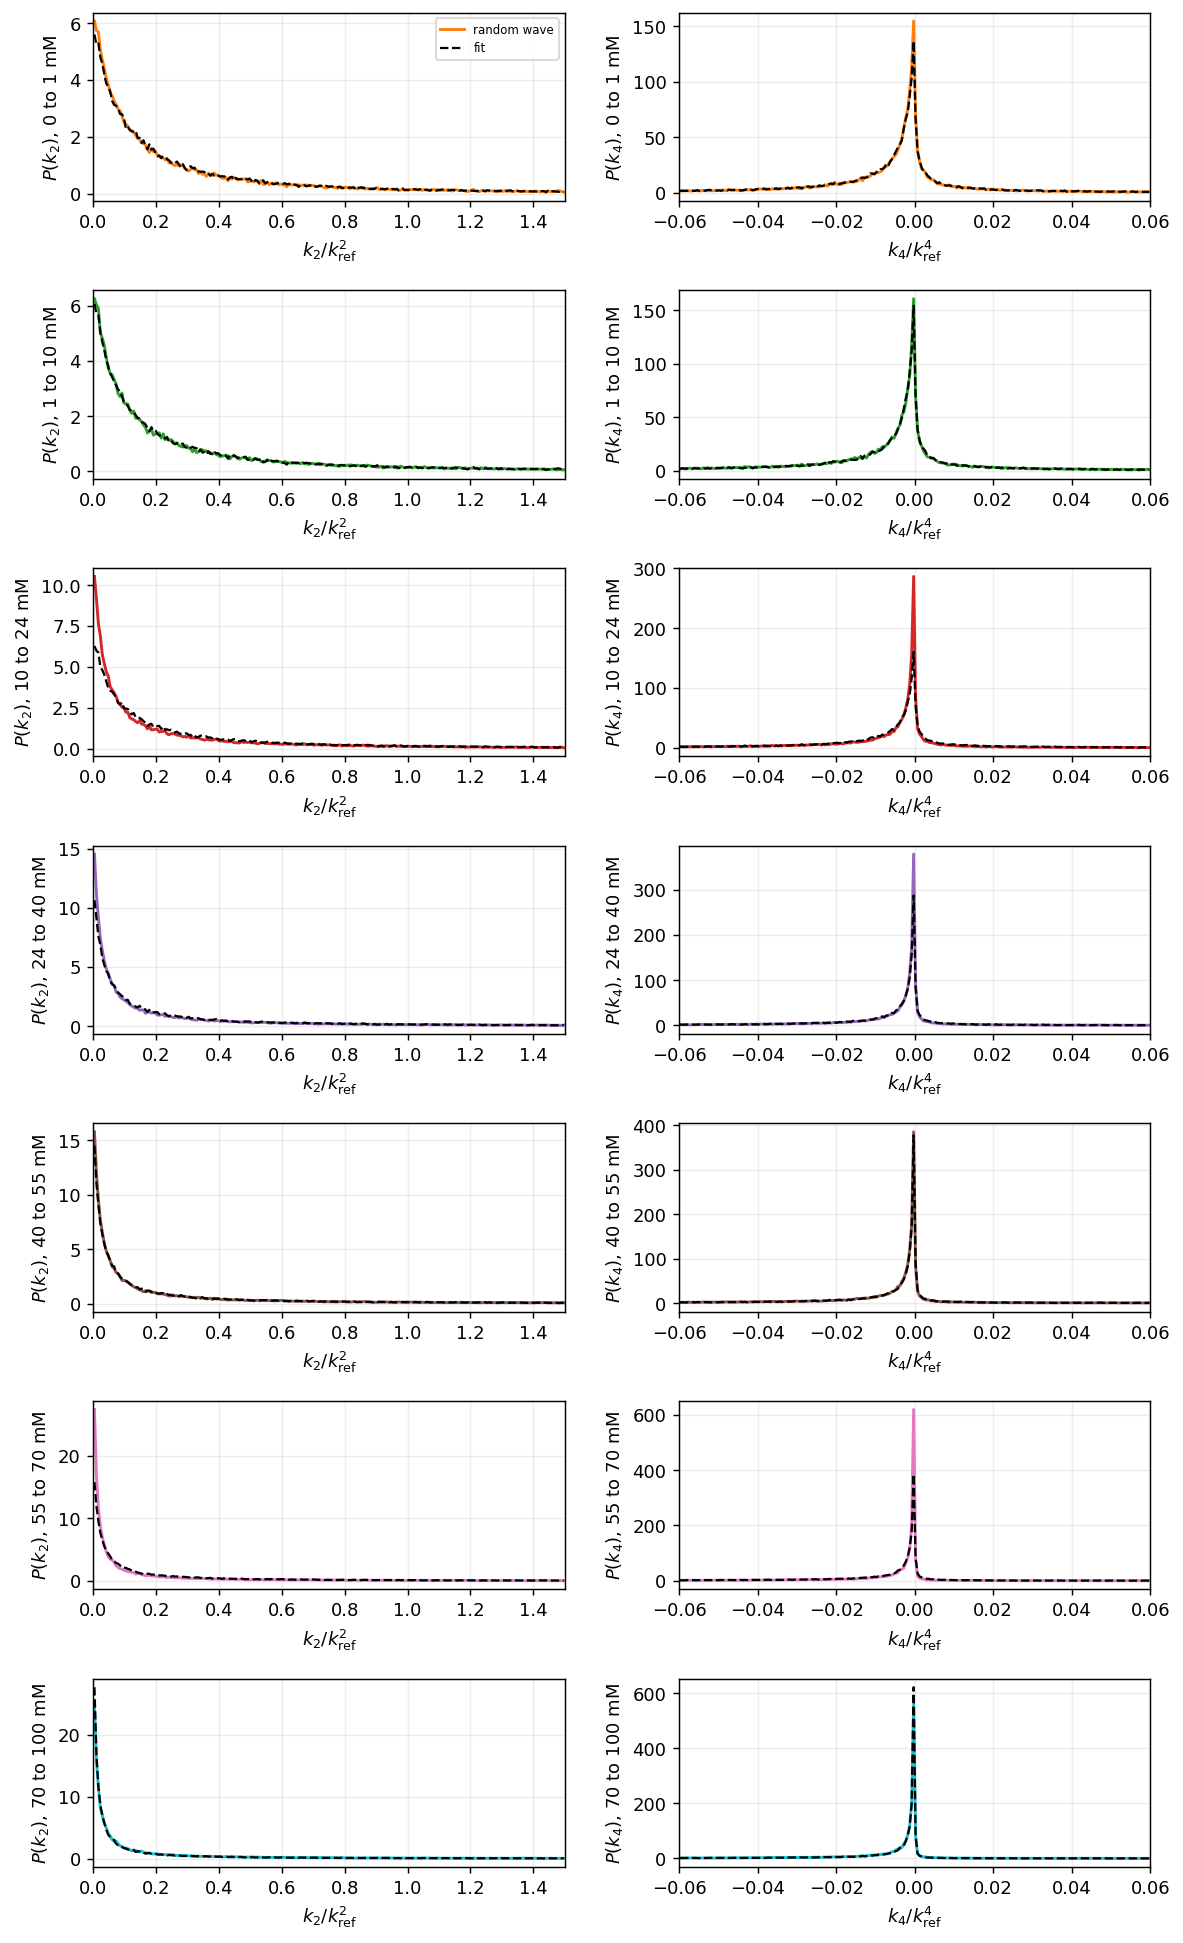

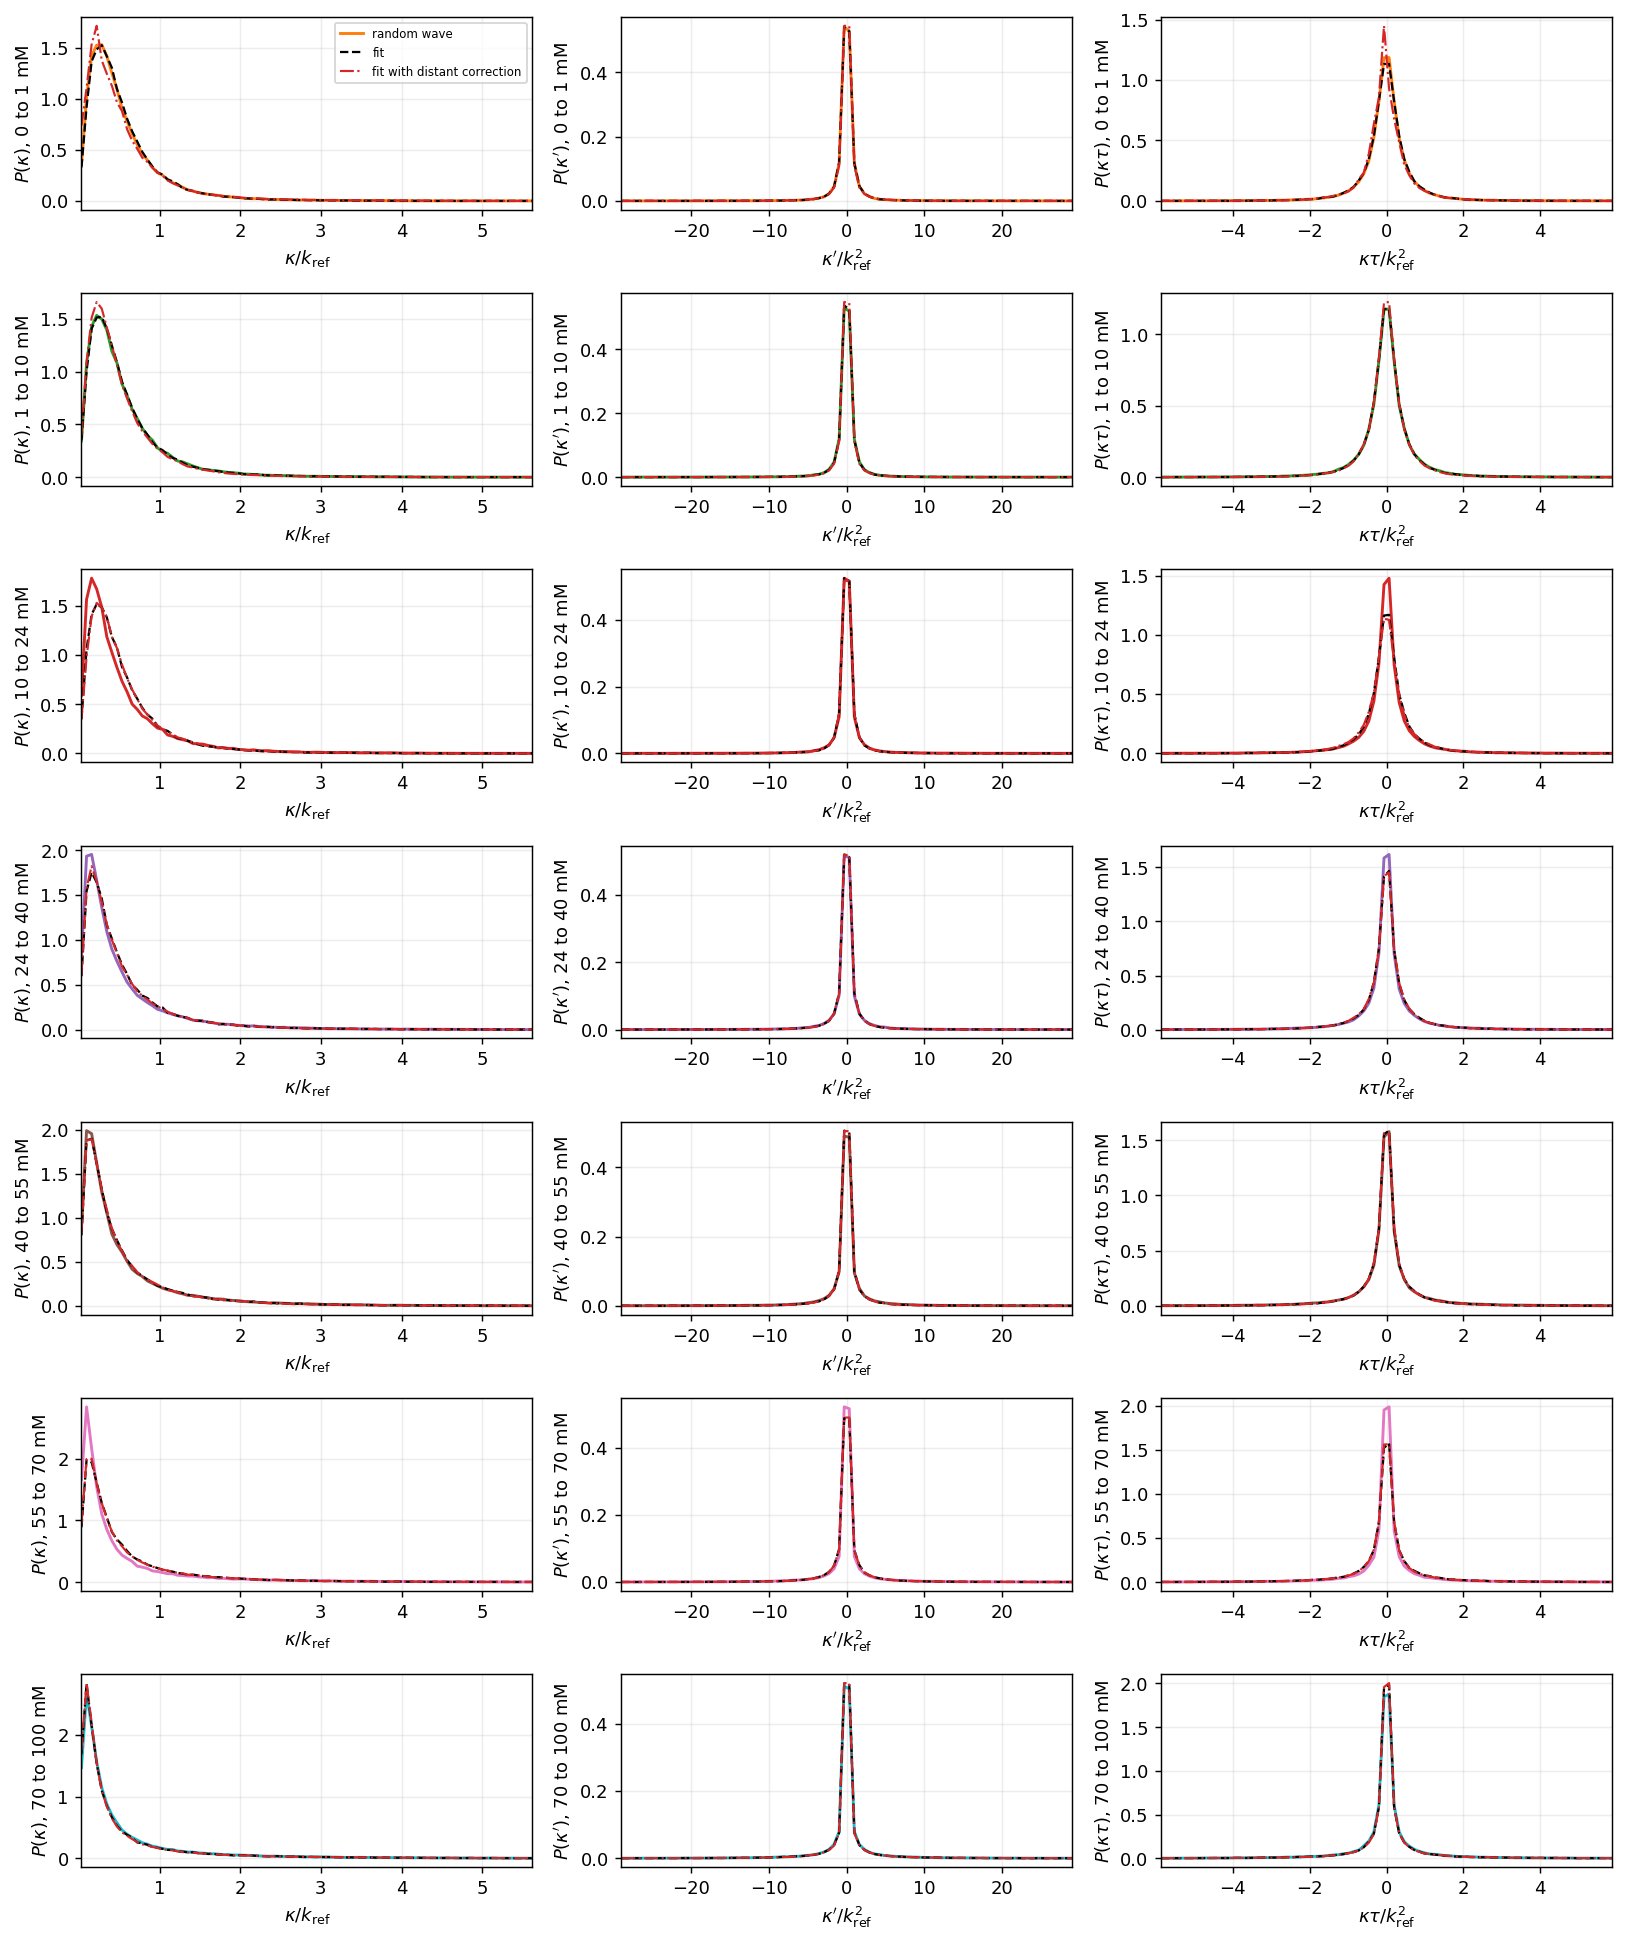

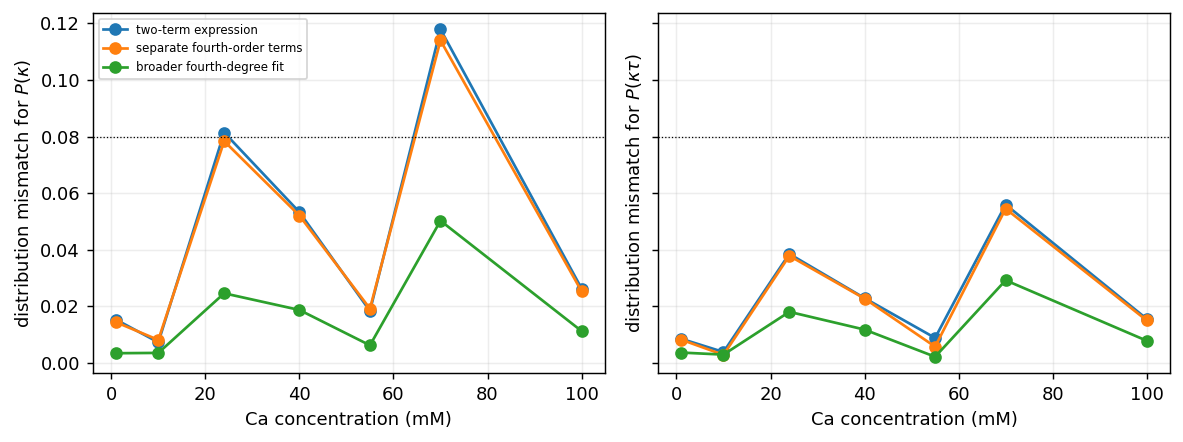

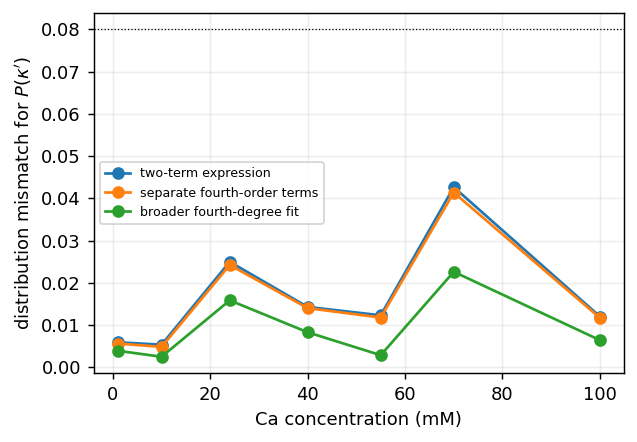

In [9]:
histogram_path = OUTPUT_DIR / "local_reconstruction_histograms.csv"
quality_path = OUTPUT_DIR / "local_reconstruction_quality.csv"
linked_distribution_adequate = False
if not histogram_path.exists() or not quality_path.exists():
    print("Fit artifacts are absent; run cf_ca_interaction_compute.ipynb with RUN_RANDOMWAVE_SAMPLING=True")
else:
    with histogram_path.open(newline="", encoding="utf-8") as handle:
        histogram_rows = list(csv.DictReader(handle))
    with quality_path.open(newline="", encoding="utf-8") as handle:
        reconstruction_quality_rows = list(csv.DictReader(handle))
    quality_by_salt = {float(row["concentration_mM"]): row for row in reconstruction_quality_rows}
    reconstruction_salt = sorted({float(row["concentration_mM"]) for row in histogram_rows})
    required_quality_columns = ("KS_kappa", "KS_kappa_prime", "KS_kappa_tau")
    if not all(column in reconstruction_quality_rows[0] for column in required_quality_columns):
        raise RuntimeError("The saved fit checks do not include kappa-prime; rerun local inference in the compute notebook")
    linked_distribution_adequate = all(max(float(quality_by_salt[float(value)][column]) for column in required_quality_columns) <= RECONSTRUCTION_KS_WARNING for value in reconstruction_salt)
    available_variables = {row["variable"] for row in histogram_rows}
    local_k2_name = "local_k2" if "local_k2" in available_variables else "linked_K2"
    local_k4_name = "local_k4" if "local_k4" in available_variables else "linked_K4"
    required_histogram_variables = {"kappa", "kappa_prime", "kappa_tau", local_k2_name, local_k4_name}
    if not required_histogram_variables.issubset(available_variables):
        raise RuntimeError("Saved distributions do not include local k2,k4; rerun local inference in the compute notebook")
    contour_histograms = []
    contour_histogram_path = OUTPUT_DIR / "contour_reconstruction_histograms.csv"
    if contour_histogram_path.exists():
        with contour_histogram_path.open(newline="", encoding="utf-8") as handle:
            saved_contour_histograms = list(csv.DictReader(handle))
        if saved_contour_histograms and saved_contour_histograms[0].get("normalization") == "common_kref" and np.isclose(float(saved_contour_histograms[0]["normalization_k_ref"]), k_ref):
            contour_histograms = saved_contour_histograms
        else:
            print("Saved contour distributions use an older normalization; rerun optional contour validation to overlay them.")
    else:
        print("Contour distributions are absent; showing random-wave measured and fit curves only.")
    corrected_histograms = []
    nonlocal_histogram_path = OUTPUT_DIR / "nonlocal_corrected_reconstruction_histograms.csv"
    nonlocal_status_path = OUTPUT_DIR / "nonlocal_corrected_coefficients.csv"
    if SHOW_DISTANT_CORRECTION_IN_FIT and nonlocal_histogram_path.exists():
        with nonlocal_histogram_path.open(newline="", encoding="utf-8") as handle:
            corrected_histograms = list(csv.DictReader(handle))
        if not corrected_histograms or "correction_applied" not in corrected_histograms[0]:
            print("Saved distant-correction results predate validation safeguards; rerun the compute notebook before displaying them.")
            corrected_histograms = []
        elif nonlocal_status_path.exists():
            with nonlocal_status_path.open(newline="", encoding="utf-8") as handle:
                correction_status_rows = list(csv.DictReader(handle))
            for row in correction_status_rows:
                if row.get("correction_applied", "False").lower() != "true":
                    print(f"{row['pair_id']}: distant correction not applied ({row.get('rejection_reason', 'validation failed')}).")
                else:
                    print(f"{row['pair_id']}: distant correction applied; K2 residual={float(row['moment_residual_K2']):.2e}, K4 residual={float(row['moment_residual_K4']):.2e}.")
    elif SHOW_DISTANT_CORRECTION_IN_FIT:
        print("No saved distant-interaction correction is available; showing the uncorrected fit only.")
    fig, axes = plt.subplots(len(reconstruction_salt), 2, figsize=(9.2, 2.15*len(reconstruction_salt)), squeeze=False)
    for row_index, concentration in enumerate(reconstruction_salt):
        color = colors[np.flatnonzero(salt == concentration)[0]]
        for column_index, (variable, xlabel, ylabel, display_range) in enumerate(((local_k2_name, r"$k_2/k_{\rm ref}^2$", r"$P(k_2)$", LOCAL_K2_HISTOGRAM_RANGE), (local_k4_name, r"$k_4/k_{\rm ref}^4$", r"$P(k_4)$", LOCAL_K4_HISTOGRAM_RANGE))):
            rows = [row for row in histogram_rows if float(row["concentration_mM"]) == concentration and row["variable"] == variable]
            contour_rows = [row for row in contour_histograms if float(row["concentration_mM"]) == concentration and row["variable"] == ("local_k2" if variable == local_k2_name else "local_k4")]
            legacy_range_factor = LOCAL_EXPANSION_RANGE_MULTIPLIER if variable.startswith("linked_") else 1.0
            coordinate = np.array([float(row["coordinate"]) for row in rows]) / legacy_range_factor
            axis = axes[row_index,column_index]
            axis.plot(coordinate, legacy_range_factor*np.array([float(row["measured_density"]) for row in rows]), color=color, lw=1.6, label="random wave")
            axis.plot(coordinate, legacy_range_factor*np.array([float(row["fit_density"]) for row in rows]), color="k", lw=1.25, ls="--", label="fit")
            if contour_rows:
                axis.plot([float(row["coordinate"]) for row in contour_rows], [float(row["measured_density"]) for row in contour_rows], color="0.45", lw=1.2, label="contour trace")
            source_salt = source_salt_by_target[concentration]
            axis.set(xlabel=xlabel, ylabel=f"{ylabel}, {source_salt:g} to {concentration:g} mM", xlim=display_range)
    axes[0,0].legend(fontsize=6.5)
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "local_k2_k4_fit.png"); plt.show()
    fig, axes = plt.subplots(len(reconstruction_salt), 3, figsize=(12.6, 2.15*len(reconstruction_salt)), squeeze=False)
    for row_index, concentration in enumerate(reconstruction_salt):
        color = colors[np.flatnonzero(salt == concentration)[0]]
        quality = quality_by_salt[float(concentration)]
        for column_index, (variable, xlabel, ylabel) in enumerate((("kappa", r"$\kappa/k_{\rm ref}$", r"$P(\kappa)$"), ("kappa_prime", r"$\kappa'/k_{\rm ref}^2$", r"$P(\kappa')$"), ("kappa_tau", r"$\kappa\tau/k_{\rm ref}^2$", r"$P(\kappa\tau)$"))):
            rows = [row for row in histogram_rows if float(row["concentration_mM"]) == concentration and row["variable"] == variable]
            contour_rows = [row for row in contour_histograms if float(row["concentration_mM"]) == concentration and row["variable"] == variable]
            coordinate = np.array([float(row["coordinate"]) for row in rows])
            measured_density = np.array([float(row["measured_density"]) for row in rows])
            fit_density = np.array([float(row["fit_density"]) for row in rows])
            axis = axes[row_index, column_index]
            axis.plot(coordinate, measured_density, color=color, lw=1.6, label="random wave")
            axis.plot(coordinate, fit_density, color="k", lw=1.25, ls="--", label="fit")
            if contour_rows:
                axis.plot([float(row["coordinate"]) for row in contour_rows], [float(row["measured_density"]) for row in contour_rows], color="0.45", lw=1.2, label="contour trace")
            corrected_rows = [row for row in corrected_histograms if float(row["concentration_mM"]) == concentration and row["variable"] == variable and row.get("correction_applied", "False").lower() == "true"]
            if corrected_rows:
                corrected_coordinate = np.array([float(row["coordinate"]) for row in corrected_rows])
                corrected_density = np.array([float(row["fit_density"]) for row in corrected_rows])
                axis.plot(corrected_coordinate, corrected_density, color="tab:red", lw=1.2, ls="-.", label="fit with distant correction")
            source_salt = source_salt_by_target[concentration]
            axis.set(xlabel=xlabel, ylabel=f"{ylabel}, {source_salt:g} to {concentration:g} mM", xlim=(coordinate.min(), coordinate.max()))
    axes[0,0].legend(fontsize=6.5)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "local_X_fit.png")
    plt.show()
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.5), sharex=True, sharey=True)
    for axis, variable, ylabel in zip(axes, ("kappa", "kappa_tau"), (r"KS for $P(\kappa)$", r"KS for $P(\kappa\tau)$")):
        linked_ks = np.array([float(quality_by_salt[float(value)][f"KS_{variable}"]) for value in reconstruction_salt])
        independent_ks = np.array([float(quality_by_salt[float(value)][f"KS_{variable}_independent"]) for value in reconstruction_salt])
        flexible_ks = np.array([float(quality_by_salt[float(value)][f"KS_{variable}_flexible"]) for value in reconstruction_salt])
        axis.plot(reconstruction_salt, linked_ks, marker="o", label="two-term expression")
        axis.plot(reconstruction_salt, independent_ks, marker="o", label="separate fourth-order terms")
        axis.plot(reconstruction_salt, flexible_ks, marker="o", label="broader fourth-degree fit")
        axis.axhline(RECONSTRUCTION_KS_WARNING, color="k", lw=0.7, ls=":")
        axis.set(xlabel="Ca concentration (mM)", ylabel=ylabel.replace("KS for", "distribution mismatch for"))
    axes[0].legend(fontsize=6.5)
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "local_reconstruction_model_quality.png"); plt.show()
    fig, axis = plt.subplots(figsize=(5.0, 3.5))
    axis.plot(reconstruction_salt, [float(quality_by_salt[float(value)]["KS_kappa_prime"]) for value in reconstruction_salt], marker="o", label="two-term expression")
    axis.plot(reconstruction_salt, [float(quality_by_salt[float(value)]["KS_kappa_prime_independent"]) for value in reconstruction_salt], marker="o", label="separate fourth-order terms")
    axis.plot(reconstruction_salt, [float(quality_by_salt[float(value)]["KS_kappa_prime_flexible"]) for value in reconstruction_salt], marker="o", label="broader fourth-degree fit")
    axis.axhline(RECONSTRUCTION_KS_WARNING, color="k", lw=0.7, ls=":")
    axis.set(xlabel="Ca concentration (mM)", ylabel=r"distribution mismatch for $P(\kappa')$")
    axis.legend(fontsize=7)
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "local_kappaprime_model_quality.png"); plt.show()
    for concentration in reconstruction_salt:
        quality = quality_by_salt[float(concentration)]
        worst = max(float(quality["KS_kappa"]), float(quality["KS_kappa_prime"]), float(quality["KS_kappa_tau"]))
        if worst > RECONSTRUCTION_KS_WARNING:
            print(f"WARNING: {concentration:g} mM is not well reproduced by the two-term expression (largest distribution mismatch={worst:.3f}).")

## 4. Conditional interaction comparison

The reference assumption and cutoff approximation are selected independently. `CONDITIONAL_REFERENCE_MODE="fixed"` uses the stated $g_0,D_0$, while `"family"` scans plausible references. `CONDITIONAL_CUTOFF_MODE="short_range"` sets $f_2=f_4=1$, while `"finite_cutoff"` retains the cutoff factors. Every result remains conditional on its selected reference treatment.

Fixed finite-cutoff mapping is incompatible with the fitted coefficient changes (changes produce nonpositive Yukawa products). Showing the explicitly labelled short-range fallback.


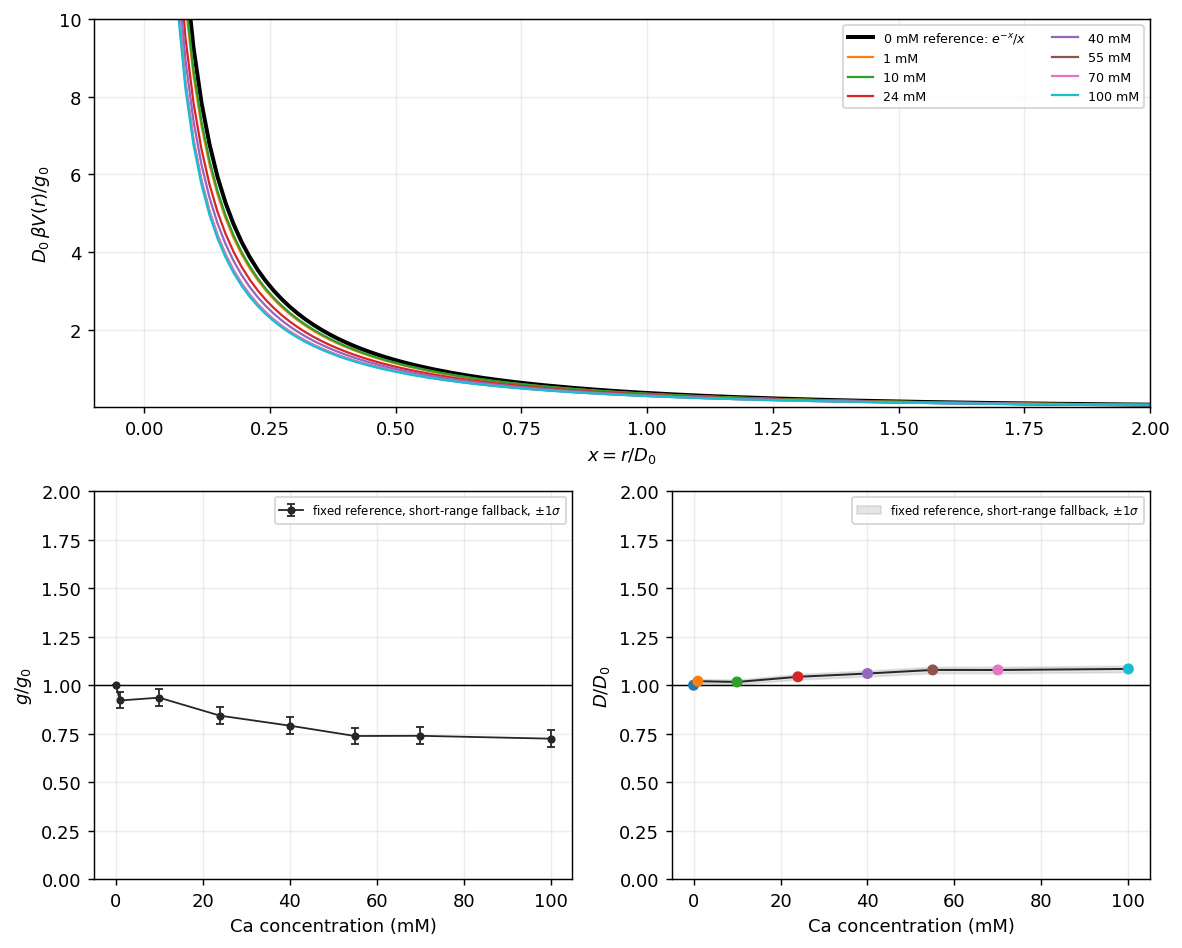

fixed reference: g0/k_ref=5, D0*k_ref=1; effective cutoff mode=short_range_fallback


In [10]:
if not linked_distribution_adequate:
    print("WARNING: interaction-parameter plots are conditional diagnostics because linked Delta c2,Delta c4 do not reproduce every observable distribution")
mapping_delta_c2 = cumulative_delta_c2
mapping_delta_c4 = cumulative_delta_c4
mapping_coefficient_covariances = cumulative_coefficient_covariances
reference_ell_kref = LOCAL_EXPANSION_RANGE_MULTIPLIER
target_ell_kref = LOCAL_EXPANSION_RANGE_MULTIPLIER * k_ref / k_eff
envelope_sigma = CONDITIONAL_ENVELOPE_STANDARD_DEVIATIONS
if CONDITIONAL_REFERENCE_MODE == "fixed" and CONDITIONAL_CUTOFF_MODE == "short_range":
    if "projection_effective_count" not in coefficient_rows[0]:
        raise RuntimeError("Saved coefficient errors use the old inflated normalization; rerun the fourth-degree fit cell in cf_ca_interaction_compute.ipynb")
    short_range_a0 = FIXED_REFERENCE_G0_OVER_KREF * FIXED_REFERENCE_D0_KREF**2 / 8.0
    short_range_c40 = FIXED_REFERENCE_G0_OVER_KREF * FIXED_REFERENCE_D0_KREF**4
    short_g, short_d = interaction.short_range_relative_yukawa_parameters(
        mapping_delta_c2, mapping_delta_c4, short_range_a0, short_range_c40
    )
    short_errors = np.array([interaction.short_range_relative_yukawa_uncertainty(
        mapping_delta_c2[index], mapping_delta_c4[index], mapping_coefficient_covariances[index],
        short_range_a0, short_range_c40,
    ) for index in range(len(salt))])
    g_plot_summary = np.column_stack((short_g, short_errors[:, 0]))
    d_plot_summary = np.column_stack((short_d, short_errors[:, 1]))
    interaction_mapping = r"conditional short-range, $\pm1\sigma$"
    mapping_cutoff_mode = "short_range"
    reported_sigma = 1.0
elif CONDITIONAL_REFERENCE_MODE == "fixed":
    fixed_a0, fixed_c40 = interaction.yukawa_dimensionless_coefficients(FIXED_REFERENCE_G0_OVER_KREF, FIXED_REFERENCE_D0_KREF, reference_ell_kref)
    try:
        fixed_g, fixed_d = interaction.relative_yukawa_parameters(mapping_delta_c2, mapping_delta_c4, float(fixed_a0), float(fixed_c40), ell_kref=target_ell_kref, reference_ell_kref=reference_ell_kref)
        fixed_errors = np.array([interaction.relative_yukawa_uncertainty(mapping_delta_c2[index], mapping_delta_c4[index], mapping_coefficient_covariances[index], float(fixed_a0), float(fixed_c40), ell_kref=target_ell_kref[index], reference_ell_kref=reference_ell_kref) for index in range(len(salt))])
        interaction_mapping = r"fixed reference with cutoff factors, $\pm1\sigma$"
        mapping_cutoff_mode = "finite_cutoff"
    except ValueError as error:
        short_range_a0 = FIXED_REFERENCE_G0_OVER_KREF * FIXED_REFERENCE_D0_KREF**2 / 8.0
        short_range_c40 = FIXED_REFERENCE_G0_OVER_KREF * FIXED_REFERENCE_D0_KREF**4
        fixed_g, fixed_d = interaction.short_range_relative_yukawa_parameters(mapping_delta_c2, mapping_delta_c4, short_range_a0, short_range_c40)
        fixed_errors = np.array([interaction.short_range_relative_yukawa_uncertainty(mapping_delta_c2[index], mapping_delta_c4[index], mapping_coefficient_covariances[index], short_range_a0, short_range_c40) for index in range(len(salt))])
        interaction_mapping = r"fixed reference, short-range fallback, $\pm1\sigma$"
        mapping_cutoff_mode = "short_range_fallback"
        print(f"Fixed finite-cutoff mapping is incompatible with the fitted coefficient changes ({error}). Showing the explicitly labelled short-range fallback.")
    g_plot_summary = np.column_stack((fixed_g, fixed_errors[:,0]))
    d_plot_summary = np.column_stack((fixed_d, fixed_errors[:,1]))
    reported_sigma = 1.0
else:
    g0_grid = np.geomspace(*CONDITIONAL_G0_OVER_KREF_BOUNDS, CONDITIONAL_REFERENCE_GRID_SIZE)
    d0_grid = np.geomspace(*CONDITIONAL_D0_KREF_BOUNDS, CONDITIONAL_REFERENCE_GRID_SIZE)
    if CONDITIONAL_CUTOFF_MODE == "short_range":
        common_family = interaction.conditional_short_range_yukawa_family(mapping_delta_c2, mapping_delta_c4, g0_grid, d0_grid)
        structural_family = common_family
    else:
        common_family = interaction.conditional_relative_yukawa_family(mapping_delta_c2, mapping_delta_c4, g0_grid, d0_grid, ell_kref=np.full_like(salt, reference_ell_kref), reference_ell_kref=reference_ell_kref)
        structural_family = interaction.conditional_relative_yukawa_family(mapping_delta_c2, mapping_delta_c4, g0_grid, d0_grid, ell_kref=target_ell_kref, reference_ell_kref=reference_ell_kref)
    joint_valid = np.all(common_family.valid, axis=1) & np.all(structural_family.valid, axis=1)
    if not np.any(joint_valid):
        raise RuntimeError("No reference choice is valid for both cutoff mappings across the full salt series")
    reference_ddof = 1 if joint_valid.sum() > 1 else 0
    g_common_values = common_family.g_over_g0[joint_valid]
    g_structural_values = structural_family.g_over_g0[joint_valid]
    d_values = structural_family.d_over_d0[joint_valid]
    g_common_summary = np.column_stack((np.mean(g_common_values, axis=0), np.std(g_common_values, axis=0, ddof=reference_ddof)))
    g_structural_summary = np.column_stack((np.mean(g_structural_values, axis=0), np.std(g_structural_values, axis=0, ddof=reference_ddof)))
    d_summary = np.column_stack((np.mean(d_values, axis=0), np.std(d_values, axis=0, ddof=reference_ddof)))
    g_plot_summary = g_common_summary
    d_plot_summary = d_summary
    interaction_mapping = f"reference family with {CONDITIONAL_CUTOFF_MODE.replace('_', ' ')}"
    mapping_cutoff_mode = CONDITIONAL_CUTOFF_MODE
    reported_sigma = envelope_sigma
reduced_distance = np.linspace(0.05, 8.0, 500)
fig = plt.figure(figsize=(9.2, 7.4))
grid = fig.add_gridspec(2, 2)
potential_axis = fig.add_subplot(grid[0, :])
g_axis = fig.add_subplot(grid[1, 0])
d_axis = fig.add_subplot(grid[1, 1])
reference_label = f"{reference_salt:g} mM reference"
g_ratio_label = r"$g/g_0$" if np.isclose(reference_salt, 0.0) else r"$g/g_{\rm ref}$"
d_ratio_label = r"$D/D_0$" if np.isclose(reference_salt, 0.0) else r"$D/D_{\rm ref}$"
distance_label = r"$x=r/D_0$" if np.isclose(reference_salt, 0.0) else r"$x=r/D_{\rm ref}$"
potential_label = r"$D_0\,\beta V(r)/g_0$" if np.isclose(reference_salt, 0.0) else r"$D_{\rm ref}\,\beta V(r)/g_{\rm ref}$"
potential_axis.plot(reduced_distance, np.exp(-reduced_distance) / reduced_distance, color="k", lw=2.2, label=reference_label + ": $e^{-x}/x$")
for color, index, concentration in zip(colors, range(len(salt)), salt):
    if index == reference_index:
        continue
    if CONDITIONAL_REFERENCE_MODE == "fixed":
        profile = interaction.normalized_yukawa_profile(reduced_distance, g_plot_summary[index,0], d_plot_summary[index,0])
    else:
        profiles = interaction.normalized_yukawa_profile(reduced_distance, structural_family.g_over_g0[joint_valid, index], structural_family.d_over_d0[joint_valid, index])
        profile = np.mean(profiles, axis=0)
    potential_axis.plot(reduced_distance, profile, color=color, lw=1.25, label=f"{concentration:g} mM")

g_axis.axhline(1.0, color="k", lw=0.8)
g_axis.errorbar(salt, g_plot_summary[:, 0], yerr=reported_sigma*g_plot_summary[:, 1], color="0.15", marker="o", ms=3.5, lw=1.0, capsize=2, label=interaction_mapping)
g_axis.set(xlabel="Ca concentration (mM)", ylabel=g_ratio_label)
g_axis.set_ylim(0.0, 2)
g_axis.legend(fontsize=6.5)

for axis, summary, ylabel in ((d_axis, d_plot_summary, d_ratio_label),):
    axis.axhline(1.0, color="k", lw=0.8)
    lower = np.maximum(summary[:, 0]-reported_sigma*summary[:, 1], 0.0)
    upper = summary[:, 0]+reported_sigma*summary[:, 1]
    axis.fill_between(salt, lower, upper, color="0.55", alpha=0.22, label=interaction_mapping)
    axis.plot(salt, summary[:, 0], color="0.15", lw=1.1)
    axis.scatter(salt, summary[:, 0], c=colors, s=26, zorder=3)
    axis.set(xlabel="Ca concentration (mM)", ylabel=ylabel)
    axis.legend(fontsize=6.5)
potential_axis.set(xlabel=distance_label, ylabel=potential_label, 
                   xscale="linear", yscale="linear", xlim=(-0.1, 2.0), ylim=(1e-2, 10.0))
potential_axis.legend(fontsize=7, ncol=2)

d_axis.set_ylim(0.0, 2.00)
fig.tight_layout()
interaction_figure = f"conditional_{CONDITIONAL_REFERENCE_MODE}_{mapping_cutoff_mode}_yukawa_comparison.png"
fig.savefig(OUTPUT_DIR / interaction_figure)
plt.show()
if CONDITIONAL_REFERENCE_MODE == "fixed":
    print(f"fixed reference: g0/k_ref={FIXED_REFERENCE_G0_OVER_KREF:g}, D0*k_ref={FIXED_REFERENCE_D0_KREF:g}; effective cutoff mode={mapping_cutoff_mode}")
else:
    print(f"reference-family choices used: {joint_valid.sum()} of {len(joint_valid)}; cutoff mode={CONDITIONAL_CUTOFF_MODE}")

In [11]:
if CONDITIONAL_REFERENCE_MODE == "fixed":
    summary_rows = [{
        "concentration_mM": concentration, "mapping": interaction_mapping,
        "g_over_g0": g_plot_summary[index, 0], "g_over_g0_error": g_plot_summary[index, 1],
        "D_over_D0": d_plot_summary[index, 0], "D_over_D0_error": d_plot_summary[index, 1],
        "g0_over_kref": FIXED_REFERENCE_G0_OVER_KREF, "D0_kref": FIXED_REFERENCE_D0_KREF, "requested_cutoff_mode": CONDITIONAL_CUTOFF_MODE, "cutoff_mode": mapping_cutoff_mode,
    } for index, concentration in enumerate(salt)]
    summary_filename = f"conditional_fixed_{mapping_cutoff_mode}_yukawa_summary.csv"
else:
    summary_rows = [{
        "concentration_mM": concentration,
        "k_eff_over_kref": k_eff[index] / k_ref,
        "target_ell_kref": target_ell_kref[index],
        "joint_valid_reference_count": int(joint_valid.sum()),
        "cutoff_mode": CONDITIONAL_CUTOFF_MODE,
        "g_over_g0_common_cutoff_mean": g_common_summary[index, 0], "g_over_g0_common_cutoff_std": g_common_summary[index, 1],
        "g_over_g0_condition_cutoff_mean": g_structural_summary[index, 0], "g_over_g0_condition_cutoff_std": g_structural_summary[index, 1],
        "D_over_D0_condition_cutoff_mean": d_summary[index, 0], "D_over_D0_condition_cutoff_std": d_summary[index, 1],
    } for index, concentration in enumerate(salt)]
    summary_filename = f"conditional_family_{CONDITIONAL_CUTOFF_MODE}_yukawa_summary.csv"
with (OUTPUT_DIR / summary_filename).open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(summary_rows[0]))
    writer.writeheader(); writer.writerows(summary_rows)
print(f"saved {interaction_mapping} summary for {len(summary_rows)} salt conditions")

saved fixed reference, short-range fallback, $\pm1\sigma$ summary for 8 salt conditions


## 5. Random-wave line-density matching

The reported $\Delta c_2$ and $\Delta c_4$ are fitted to the random-wave samples. This figure therefore treats the random-wave target and random-wave fit as the primary comparison. Traced-contour values and their separate fit are shown only as an optional resolution and finite-size check. All curves are line densities using the same fixed reference normalization: $\langle k_2\rangle/k_{\rm ref}^2=(K_2/L)/k_{\rm ref}^2$ and $\langle k_4\rangle/k_{\rm ref}^4=(K_4/L)/k_{\rm ref}^4$. No contour-length ratio or three-dimensional cell volume is applied.

Contour validation is absent; only the primary random-wave comparison is shown.


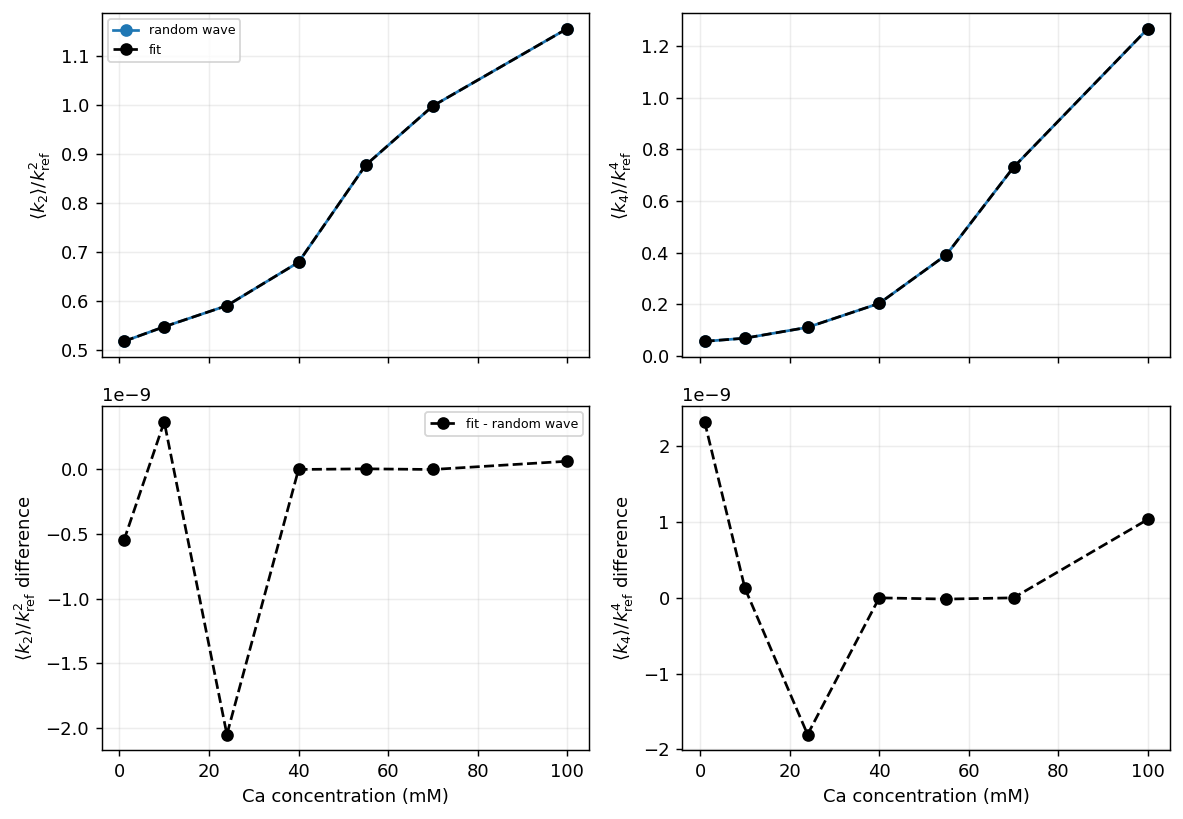

In [12]:
randomwave_rows = [row for row in coefficient_rows if row["randomwave_target_K2_over_ksource"].lower() != "nan"]
comparison_salt = np.array([float(row["concentration_mM"]) for row in randomwave_rows])
source_scale = np.array([float(row["source_k_eff"])/k_ref for row in randomwave_rows])
randomwave_k2 = np.array([float(row["randomwave_target_K2_over_ksource"]) for row in randomwave_rows]) * source_scale**2 / LOCAL_EXPANSION_RANGE_MULTIPLIER
randomwave_fitted_k2 = np.array([float(row["randomwave_fitted_K2_over_ksource"]) for row in randomwave_rows]) * source_scale**2 / LOCAL_EXPANSION_RANGE_MULTIPLIER
randomwave_k4 = np.array([float(row["randomwave_target_K4_over_ksource3"]) for row in randomwave_rows]) * source_scale**4 / LOCAL_EXPANSION_RANGE_MULTIPLIER
randomwave_fitted_k4 = np.array([float(row["randomwave_fitted_K4_over_ksource3"]) for row in randomwave_rows]) * source_scale**4 / LOCAL_EXPANSION_RANGE_MULTIPLIER
contour_values = None
contour_validation_path = OUTPUT_DIR / "contour_validation.csv"
if contour_validation_path.exists():
    with contour_validation_path.open(newline="", encoding="utf-8") as handle:
        contour_validation_rows = list(csv.DictReader(handle))
    contour_columns = {"contour_target_k2_density_over_kref2", "contour_fitted_k2_density_over_kref2", "contour_target_k4_density_over_kref4", "contour_fitted_k4_density_over_kref4"}
    if contour_validation_rows and contour_columns.issubset(contour_validation_rows[0]):
        contour_by_salt = {float(row["concentration_mM"]): row for row in contour_validation_rows}
        if all(value in contour_by_salt for value in comparison_salt):
            contour_k2 = np.array([float(contour_by_salt[value]["contour_target_k2_density_over_kref2"]) for value in comparison_salt])
            contour_fitted_k2 = np.array([float(contour_by_salt[value]["contour_fitted_k2_density_over_kref2"]) for value in comparison_salt])
            contour_k4 = np.array([float(contour_by_salt[value]["contour_target_k4_density_over_kref4"]) for value in comparison_salt])
            contour_fitted_k4 = np.array([float(contour_by_salt[value]["contour_fitted_k4_density_over_kref4"]) for value in comparison_salt])
            contour_values = (contour_k2, contour_fitted_k2, contour_k4, contour_fitted_k4)
    if contour_values is None:
        print("Saved contour validation uses an older normalization; only the primary random-wave comparison is shown.")
else:
    print("Contour validation is absent; only the primary random-wave comparison is shown.")
fig, axes = plt.subplots(2, 2, figsize=(9.2, 6.4), sharex=True)
for axis, randomwave_value, randomwave_fit, ylabel in ((axes[0,0], randomwave_k2, randomwave_fitted_k2, r"$\langle k_2\rangle/k_{\rm ref}^2$"), (axes[0,1], randomwave_k4, randomwave_fitted_k4, r"$\langle k_4\rangle/k_{\rm ref}^4$")):
    axis.plot(comparison_salt, randomwave_value, marker="o", label="random wave")
    axis.plot(comparison_salt, randomwave_fit, color="k", marker="o", ls="--", label="fit")
    axis.set(ylabel=ylabel)
axes[1,0].plot(comparison_salt, randomwave_fitted_k2-randomwave_k2, color="k", marker="o", ls="--", label="fit - random wave")
axes[1,1].plot(comparison_salt, randomwave_fitted_k4-randomwave_k4, color="k", marker="o", ls="--")
if contour_values is not None:
    axes[0,0].plot(comparison_salt, contour_k2, color="0.45", marker="s", label="contour trace")
    axes[0,0].plot(comparison_salt, contour_fitted_k2, color="0.45", marker="s", ls=":", label="contour fit")
    axes[0,1].plot(comparison_salt, contour_k4, color="0.45", marker="s", label="contour trace")
    axes[0,1].plot(comparison_salt, contour_fitted_k4, color="0.45", marker="s", ls=":", label="contour fit")
    axes[1,0].plot(comparison_salt, contour_k2-randomwave_k2, marker="o", label="contour trace - random wave")
    axes[1,1].plot(comparison_salt, contour_k4-randomwave_k4, marker="o")
axes[1,0].set(xlabel="Ca concentration (mM)", ylabel=r"$\langle k_2\rangle/k_{\rm ref}^2$ difference")
axes[1,1].set(xlabel="Ca concentration (mM)", ylabel=r"$\langle k_4\rangle/k_{\rm ref}^4$ difference")
axes[0,0].legend(fontsize=7); axes[1,0].legend(fontsize=7)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "k2_k4_line_density_comparison.png"); plt.show()

## Interaction-form-independent distant correction

The radial coefficients describe a finite numerical representation of the interaction change. They are shown only with the overlap and identifiability checks from the joint fit.

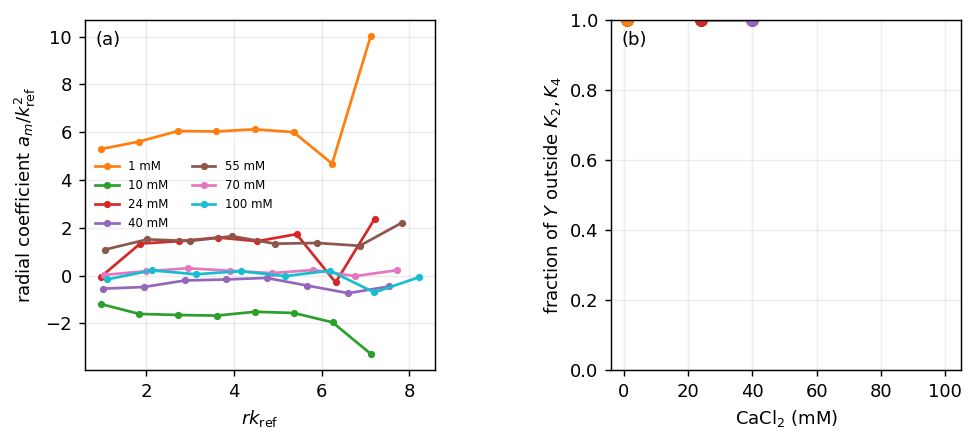

In [13]:
if NONLOCAL_METHOD == "model_free":
    radial_path = OUTPUT_DIR / "model_free_radial_coefficients.csv"
    diagnostic_path = OUTPUT_DIR / "model_free_identifiability.csv"
    status_path = OUTPUT_DIR / "nonlocal_corrected_coefficients.csv"
    if not (radial_path.exists() and diagnostic_path.exists() and status_path.exists()):
        print("Model-free results are absent; run the compute notebook with RUN_NONLOCAL_CORRECTION=True.")
    else:
        with radial_path.open(newline="", encoding="utf-8") as handle: radial_rows = list(csv.DictReader(handle))
        with diagnostic_path.open(newline="", encoding="utf-8") as handle: diagnostic_rows = list(csv.DictReader(handle))
        with status_path.open(newline="", encoding="utf-8") as handle: status_rows = list(csv.DictReader(handle))
        fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.5))
        radial_salt = np.array(sorted({float(row["concentration_mM"]) for row in radial_rows}))
        for concentration in radial_salt:
            color = colors[int(np.flatnonzero(np.isclose(salt, concentration))[0])]
            rows = [row for row in radial_rows if np.isclose(float(row["concentration_mM"]), concentration)]
            axes[0].plot([float(row["radial_distance"])*k_ref for row in rows], [float(row["radial_coefficient"])/k_ref**2 for row in rows], color=color, marker="o", ms=3, label=f"{concentration:g} mM")
        accepted = {float(row["concentration_mM"]): row.get("correction_applied", "False").lower() == "true" for row in status_rows}
        diagnostic_salt = np.array(sorted({float(row["concentration_mM"]) for row in diagnostic_rows}))
        orthogonal = np.array([float(next(row for row in diagnostic_rows if np.isclose(float(row["concentration_mM"]), value))["orthogonal_Y_fraction"]) for value in diagnostic_salt])
        axes[1].plot(diagnostic_salt, orthogonal, color="k", marker="o")
        for concentration, value, color in zip(diagnostic_salt, orthogonal, colors[-len(diagnostic_salt):]):
            axes[1].plot(concentration, value, marker="o" if accepted.get(concentration, False) else "x", color=color)
        axes[0].set(xlabel=r"$r k_{\rm ref}$", ylabel=r"radial coefficient $a_m/k_{\rm ref}^2$")
        axes[1].set(xlabel=r"CaCl$_2$ (mM)", ylabel=r"fraction of $Y$ outside $K_2,K_4$", ylim=(0,1))
        for axis, label in zip(axes, ("(a)", "(b)")):
            axis.set_box_aspect(1); axis.text(0.03, 0.97, label, transform=axis.transAxes, ha="left", va="top")
        axes[0].legend(loc="best", ncol=2, fontsize=6.5, frameon=False)
        fig.tight_layout(); fig.savefig(OUTPUT_DIR / "model_free_nonlocal_summary.png", bbox_inches="tight"); plt.show()